# MecâniQA - OAT 1 - MACEIÓ

Notebook destinado ao carregamento e à inspeção inicial do dataset da MecâniQA.

In [1]:
import pandas as pd

In [2]:
from google.colab import files

arquivo = files.upload()

Saving mecaniqa_dataset - mecaniqa_dataset.csv.csv to mecaniqa_dataset - mecaniqa_dataset.csv.csv


In [3]:
df = pd.read_csv("mecaniqa_dataset - mecaniqa_dataset.csv.csv")

In [4]:
df["Data"] = pd.to_datetime(df["Data"])
df = df.set_index("Data")

In [5]:
df.head()

,Trocas_Oleo,Manutencao_Motor
Data,,
2024-01-01,11.0,2.0
2024-01-02,9.0,4.0
2024-01-03,12.0,1.0
2024-01-04,15.0,8.0
2024-01-05,25.0,10.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 731 entries, 2024-01-01 to 2025-12-31
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Trocas_Oleo       725 non-null    float64
 1   Manutencao_Motor  728 non-null    float64
dtypes: float64(2)
memory usage: 17.1 KB


In [7]:
df = df.sort_index()

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [9]:
serie = df["Trocas_Oleo"].interpolate()

In [10]:
decomposicao = seasonal_decompose(
    serie,
    model="additive",
    period=7
)

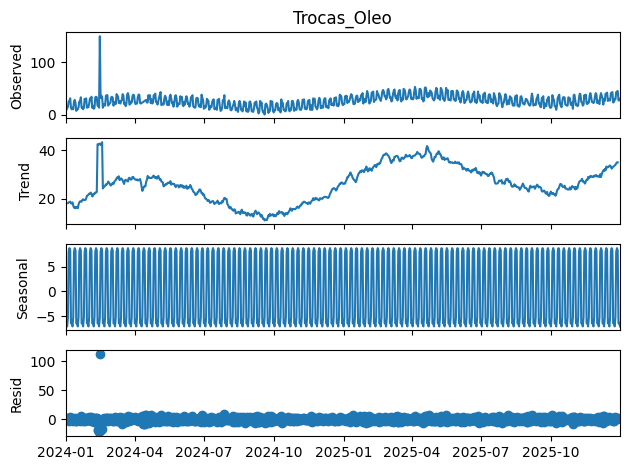

In [11]:
import matplotlib.pyplot as plt

fig = decomposicao.plot()

fig.axes[0].set_ylabel("Observed")
fig.axes[0].set_title("Trocas_Oleo")

plt.show()

In [12]:
from sklearn.pipeline import Pipeline

In [13]:
dados_modelo = df[["Trocas_Oleo", "Manutencao_Motor"]].copy()
dados_modelo["Trocas_Oleo_Amanha"] = dados_modelo["Trocas_Oleo"].shift(-1)
dados_modelo = dados_modelo.dropna(subset=["Trocas_Oleo_Amanha"])

In [14]:
X = dados_modelo[["Trocas_Oleo", "Manutencao_Motor"]]
y = dados_modelo["Trocas_Oleo_Amanha"]

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(    X, y, test_size=0.2, shuffle=False)

In [17]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [18]:
from sklearn.linear_model import LinearRegression

In [19]:
pipeline = Pipeline([
    ("imputer", SimpleImputer()),
    ("scaler", StandardScaler()),
    ("modelo", LinearRegression())
])

In [20]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('modelo', LinearRegression())])

MecâniQA - OAT 2 - MACEIÓ
Baseline e métricas de avaliação

In [21]:
def modelo_naive(serie):
    return serie.shift(1)

In [22]:
def media_movel(serie, janela=7):
    return serie.shift(1).rolling(window=janela).mean()

In [23]:
df["Previsao_Naive"] = modelo_naive(df["Trocas_Oleo"])
df["Previsao_Media_Movel"] = media_movel(df["Trocas_Oleo"], janela=7)

df[["Trocas_Oleo", "Previsao_Naive", "Previsao_Media_Movel"]].head(10)

,Trocas_Oleo,Previsao_Naive,Previsao_Media_Movel
Data,,,
2024-01-01,11.0,NaN,NaN
2024-01-02,9.0,11.0,NaN
2024-01-03,12.0,9.0,NaN
2024-01-04,15.0,12.0,NaN
2024-01-05,25.0,15.0,NaN
2024-01-06,25.0,25.0,NaN
2024-01-07,31.0,25.0,NaN
2024-01-08,13.0,31.0,18.285714
2024-01-09,10.0,13.0,18.571429


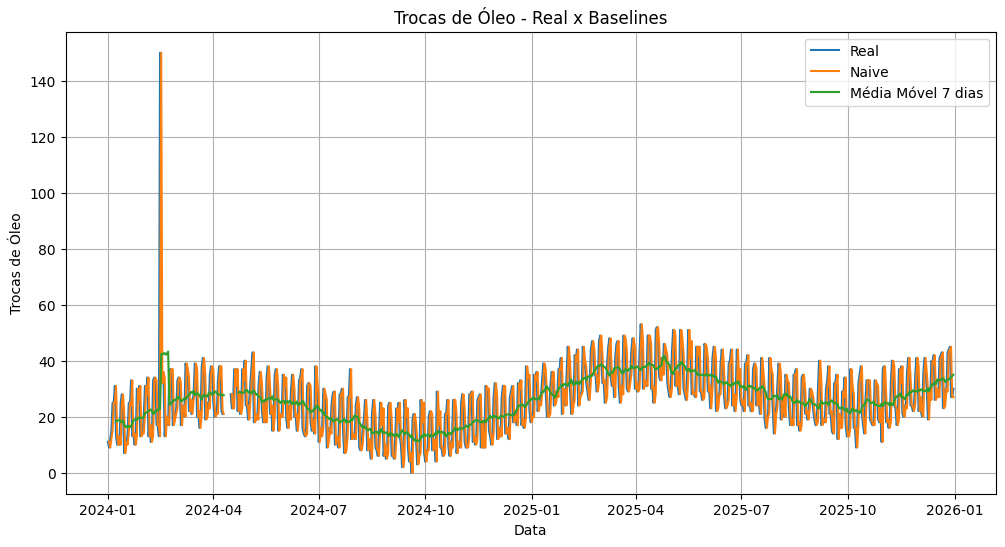

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(df.index, df["Trocas_Oleo"], label="Real")
plt.plot(df.index, df["Previsao_Naive"], label="Naive")
plt.plot(df.index, df["Previsao_Media_Movel"], label="Média Móvel 7 dias")

plt.title("Trocas de Óleo - Real x Baselines")
plt.xlabel("Data")
plt.ylabel("Trocas de Óleo")
plt.legend()
plt.grid(True)

plt.show()

In [25]:
from sklearn.model_selection import TimeSeriesSplit

In [30]:
tscv = TimeSeriesSplit(n_splits=5)

In [31]:
for i, (train_idx, test_idx) in enumerate(tscv.split(df)):
    print(f"Split {i+1}")
    print(f"Treino: {len(train_idx)} registros")
    print(f"Teste: {len(test_idx)} registros")
    print()

Split 1
Treino: 126 registros
Teste: 121 registros

Split 2
Treino: 247 registros
Teste: 121 registros

Split 3
Treino: 368 registros
Teste: 121 registros

Split 4
Treino: 489 registros
Teste: 121 registros

Split 5
Treino: 610 registros
Teste: 121 registros



In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

In [38]:
def avaliar_modelo(y_real, y_prev):
    mae = mean_absolute_error(y_real, y_prev)
    rmse = np.sqrt(mean_squared_error(y_real, y_prev))

    mascara = y_real != 0
    mape = mean_absolute_percentage_error(
        y_real[mascara],
        y_prev[mascara]
    ) * 100

    return mae, rmse, mape

In [39]:
resultados_naive = []

for _, test_idx in tscv.split(df):
    teste = df.iloc[test_idx][["Trocas_Oleo", "Previsao_Naive"]].dropna()

    mae, rmse, mape = avaliar_modelo(
        teste["Trocas_Oleo"],
        teste["Previsao_Naive"]
    )

    resultados_naive.append([mae, rmse, mape])

media_naive = np.mean(resultados_naive, axis=0)

print(
    f"Resultados do Baseline Naive - "
    f"MAE: {media_naive[0]:.2f}, "
    f"RMSE: {media_naive[1]:.2f}, "
    f"MAPE: {media_naive[2]:.2f}%"
)

Resultados do Baseline Naive - MAE: 6.65, RMSE: 8.92, MAPE: 32.64%


In [40]:
resultados_media_movel = []

for _, test_idx in tscv.split(df):
    teste = df.iloc[test_idx][["Trocas_Oleo", "Previsao_Media_Movel"]].dropna()

    mae, rmse, mape = avaliar_modelo(
        teste["Trocas_Oleo"],
        teste["Previsao_Media_Movel"]
    )

    resultados_media_movel.append([mae, rmse, mape])

media_mm = np.mean(resultados_media_movel, axis=0)

print(
    f"Resultados do Baseline Média Móvel - "
    f"MAE: {media_mm[0]:.2f}, "
    f"RMSE: {media_mm[1]:.2f}, "
    f"MAPE: {media_mm[2]:.2f}%"
)

Resultados do Baseline Média Móvel - MAE: 7.36, RMSE: 8.09, MAPE: 37.22%


In [41]:
print(
    f"Resultados do Baseline Naive - "
    f"MAE: {media_naive[0]:.2f}, "
    f"RMSE: {media_naive[1]:.2f}, "
    f"MAPE: {media_naive[2]:.2f}%"
)

print(
    f"Resultados do Baseline Média Móvel - "
    f"MAE: {media_mm[0]:.2f}, "
    f"RMSE: {media_mm[1]:.2f}, "
    f"MAPE: {media_mm[2]:.2f}%"
)

Resultados do Baseline Naive - MAE: 6.65, RMSE: 8.92, MAPE: 32.64%
Resultados do Baseline Média Móvel - MAE: 7.36, RMSE: 8.09, MAPE: 37.22%
